In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
from scipy.io import wavfile
from IPython.display import Audio, display
import os, time
np.random.seed(0)

## Άσκηση — Ετεροσυσχέτιση και Φασματικές Πυκνότητες

### 1. Ετεροσυσχέτιση ακολουθιών & εκτιμητές

Για δύο πραγματικές ακολουθίες, η **ετεροσυσχέτιση** ορίζεται ως

$$r_{xy}[l] = \sum_{n=-\infty}^{\infty} x[n]\,y[n+l],$$

με $l$ την **υστέρηση σε δείγματα**. Στην πράξη έχουμε $N$ δείγματα, οπότε χρησιμοποιούμε **εκτιμητές**. Δύο συνηθισμένοι εκτιμητές της αυτοσυσχέτισης είναι:

$$\hat r^{\text{biased}}_x[l] = \frac{1}{N}\sum_{n} x[n]x[n+l], \qquad \hat r^{\text{unbiased}}_x[l] = \frac{1}{N-|l|}\sum_{n} x[n]x[n+l].$$

Η επιλογή **έχει σημασία**:
* Ο **αμερόληπτος** έχει σωστή μέση τιμή, αλλά για μεγάλα $|l|$ διαιρεί με μικρό $N-|l|$ → **τεράστια διακύμανση** στις άκρες (θορυβώδης «ουρά»).
* Ο **μεροληπτικός** υποεκτιμά τις ουρές (τις πολλαπλασιάζει με ένα τριγωνικό παράθυρο Bartlett), αλλά είναι **θετικά ημιορισμένος** — άρα δίνει πάντα μη-αρνητικό φάσμα ισχύος. Γι' αυτό ο μεροληπτικός προτιμάται όταν στη συνέχεια θα πάρουμε μετασχ. Fourier (Wiener–Khinchin).

In [12]:
# ============================================================
#  Φόρτωση σημάτων: χρησιμοποιεί τα ΔΙΚΑ ΣΑΣ αρχεία αν υπάρχουν
#  στον φάκελο  files/  (files/speech.wav, files/music.wav).
#  Αν δεν βρεθούν, δημιουργούνται ΣΥΝΘΕΤΙΚΑ σήματα ομιλίας/μουσικής
#  ώστε το notebook να τρέχει αυτόνομα για επίδειξη.
# ============================================================

def _formant(x, fc, bw, fs):
    """Απλός συντονιστής 2ης τάξης (μοντελοποιεί έναν φορμάντ)."""
    r = np.exp(-np.pi * bw / fs)
    th = 2 * np.pi * fc / fs
    a = [1.0, -2 * r * np.cos(th), r * r]
    return sig.lfilter([1.0 - r], a, x)

def synth_speech(fs=16000):
    """Συνθετική 'ομιλία': έμφωνο /a/ (περιοδικό) + άφωνο τμήμα (θόρυβος)."""
    dur_v = 0.8
    n = np.arange(int(dur_v * fs))
    f0 = 120.0
    P = int(round(fs / f0))
    e = np.zeros_like(n, dtype=float)
    e[::P] = 1.0
    v = _formant(e, 730, 90, fs)
    v = _formant(v, 1090, 110, fs)
    v = _formant(v, 2440, 160, fs)
    v /= (np.max(np.abs(v)) + 1e-12)
    sil = np.zeros(int(0.1 * fs))
    unv = np.random.randn(int(0.6 * fs))
    b, a = sig.butter(4, 3000 / (fs / 2), 'high')
    unv = sig.lfilter(b, a, unv)
    unv *= 0.3 / (np.max(np.abs(unv)) + 1e-12)
    x = np.concatenate([v, sil, unv]).astype(float)
    return fs, x / (np.max(np.abs(x)) + 1e-12)

def synth_music(fs=16000):
    """Συνθετική 'μουσική': δύο διαδοχικές συγχορδίες με αρμονικές & φθορά."""
    def chord(freqs, dur):
        n = np.arange(int(dur * fs))
        t = n / fs
        env = np.exp(-3.0 * t)
        y = np.zeros_like(t)
        for f in freqs:
            for h, amp in enumerate([1.0, 0.5, 0.33, 0.25], start=1):
                y += amp * np.sin(2 * np.pi * f * h * t)
        return y * env
    C = chord([261.63, 329.63, 392.00], 1.0)
    G = chord([392.00, 493.88, 587.33], 1.0)
    x = np.concatenate([C, G]).astype(float)
    return fs, x / (np.max(np.abs(x)) + 1e-12)

def load_signal(kind):
    """kind: 'speech' ή 'music'. Επιστρέφει (fs, x) μονοφωνικό, κανονικοποιημένο."""
    path = os.path.join('files', kind + '.wav')
    if os.path.exists(path):
        fs, x = wavfile.read(path)
        x = x.astype(np.float64)
        if x.ndim > 1:
            x = x.mean(axis=1)
        x /= (np.max(np.abs(x)) + 1e-12)
        print(f"Φορτώθηκε: {path}  (fs={fs} Hz, διάρκεια={len(x)/fs:.2f} s)")
        return fs, x
    print(f"[!] Δεν βρέθηκε {path} -> χρήση ΣΥΝΘΕΤΙΚΟΥ σήματος '{kind}'.")
    return (synth_speech() if kind == 'speech' else synth_music())

In [13]:
fs_sp, speech = load_signal('speech')
fs_mu, music  = load_signal('music')
print('N (ομιλία) =', len(speech), '  N (μουσική) =', len(music))

[!] Δεν βρέθηκε files\speech.wav -> χρήση ΣΥΝΘΕΤΙΚΟΥ σήματος 'speech'.
[!] Δεν βρέθηκε files\music.wav -> χρήση ΣΥΝΘΕΤΙΚΟΥ σήματος 'music'.
N (ομιλία) = 24000   N (μουσική) = 32000


### 2. Υλοποίηση: `np.correlate` vs `scipy.signal.correlate` και οι δύο εκτιμητές

Το `sig.correlate(x, x, 'full')` δίνει το **μη-κανονικοποιημένο** άθροισμα $\sum_n x[n]x[n+l]$ για όλες τις υστερήσεις. Το `sig.correlation_lags` δίνει τον άξονα $l$. Για μεγάλα σήματα, το `method='fft'` (ή `sig.fftconvolve`) είναι δραματικά ταχύτερο από τον ορισμό $O(N^2)$. Ας δούμε και τους δύο εκτιμητές στο ίδιο έμφωνο τμήμα, και ας χρονομετρήσουμε άμεσο vs FFT.

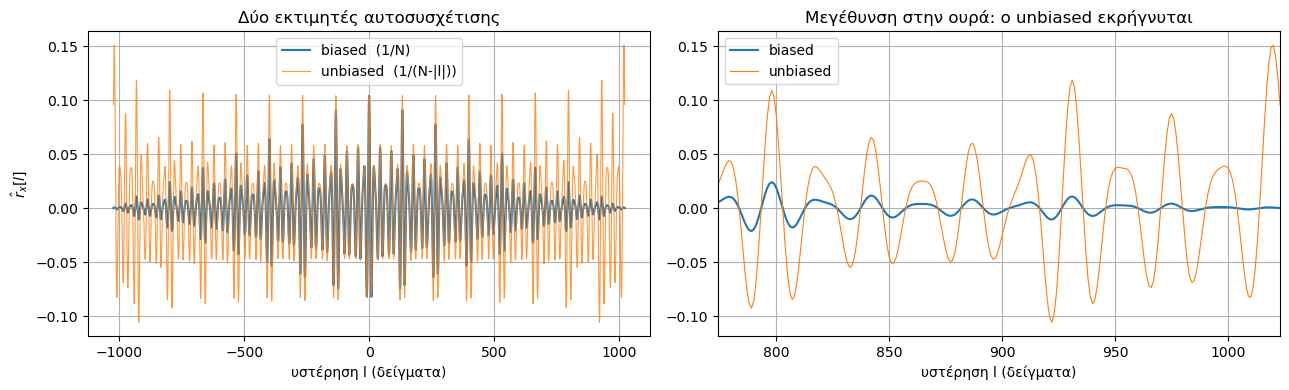

Άμεσος O(N^2): 84.1 ms   |   FFT: 2.7 ms   |   επιτάχυνση ~31x


In [14]:
seg = speech[int(0.30*fs_sp):int(0.30*fs_sp)+1024].astype(float)
seg = seg - np.mean(seg)
Nseg = len(seg)

raw = sig.correlate(seg, seg, mode='full')          # μη-κανονικοποιημένο άθροισμα
lags = sig.correlation_lags(Nseg, Nseg, mode='full')
r_biased   = raw / Nseg
r_unbiased = raw / (Nseg - np.abs(lags))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(lags, r_biased, label='biased  (1/N)')
ax[0].plot(lags, r_unbiased, lw=0.8, alpha=0.8, label='unbiased  (1/(N-|l|))')
ax[0].set_xlabel('υστέρηση l (δείγματα)'); ax[0].set_ylabel(r'$\hat r_x[l]$')
ax[0].set_title('Δύο εκτιμητές αυτοσυσχέτισης'); ax[0].legend(); ax[0].grid(True)
ax[1].plot(lags, r_biased, label='biased'); ax[1].plot(lags, r_unbiased, lw=0.8, label='unbiased')
ax[1].set_xlim(Nseg-250, Nseg-1)
ax[1].set_title('Μεγέθυνση στην ουρά: ο unbiased εκρήγνυται')
ax[1].set_xlabel('υστέρηση l (δείγματα)'); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

# Χρονομέτρηση: άμεσος ορισμός vs FFT σε μεγάλο σήμα
big = speech.astype(float)
t0 = time.perf_counter(); sig.correlate(big, big, mode='full', method='direct'); td = time.perf_counter()-t0
t0 = time.perf_counter(); sig.correlate(big, big, mode='full', method='fft');    tf = time.perf_counter()-t0
print(f'Άμεσος O(N^2): {td*1e3:.1f} ms   |   FFT: {tf*1e3:.1f} ms   |   επιτάχυνση ~{td/tf:.0f}x')

Η **κανονικοποιημένη** ετεροσυσχέτιση $\rho_{xy}[l]=r_{xy}[l]/\sqrt{r_x[0]\,r_y[0]}$ βρίσκεται στο $[-1,1]$ και είναι το κατάλληλο μέτρο **ομοιότητας** ανεξάρτητα από την ενέργεια των σημάτων — θα το χρησιμοποιήσουμε στην εκτίμηση καθυστέρησης.

### 3. Θεώρημα Wiener–Khinchin σε διακριτό χρόνο — το περιοδόγραμμα

Η **PSD διακριτού χρόνου** είναι ο DTFT της αυτοσυσχέτισης: $S_x(e^{j\omega})=\sum_l r_x[l]\,e^{-j\omega l}$. Ο απλούστερος εκτιμητής της είναι το **περιοδόγραμμα**

$$\hat S^{\text{per}}_x[k] = \frac{1}{N}\,\big|X[k]\big|^2, \qquad X[k]=\text{DFT}\{x[n]\}.$$

Δεν είναι σύμπτωση: **το περιοδόγραμμα ισούται με τον DFT του μεροληπτικού εκτιμητή αυτοσυσχέτισης** — η διακριτή μορφή του Wiener–Khinchin. Ας το επαληθεύσουμε αριθμητικά (μέχρι αριθμητικό σφάλμα).

Μέγιστη |περιοδόγραμμα - DFT{r_biased}| : 3.076650045841234e-12


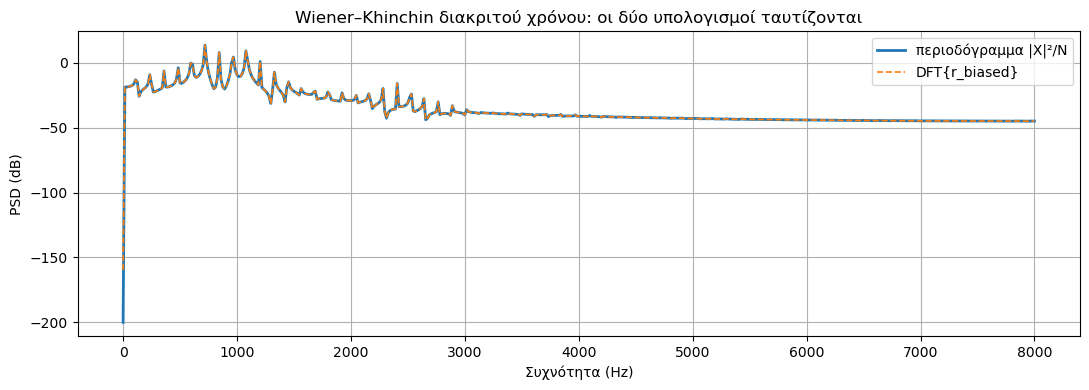

In [15]:
x = seg.copy()
N = len(x)
X = np.fft.fft(x)
per = (np.abs(X)**2) / N                              # περιοδόγραμμα

# DFT του μεροληπτικού εκτιμητή αυτοσυσχέτισης, δειγματοληπτημένος στις συχνότητες του DFT
r = sig.correlate(x, x, mode='full') / N             # biased, υστερήσεις -(N-1)..(N-1)
l = sig.correlation_lags(N, N, mode='full')
k = np.arange(N)
S_from_r = np.array([np.sum(r * np.exp(-1j*2*np.pi*kk*l/N)) for kk in k]).real

print('Μέγιστη |περιοδόγραμμα - DFT{r_biased}| :', np.max(np.abs(per - S_from_r)))

f = np.fft.rfftfreq(N, 1/fs_sp)
plt.figure(figsize=(11, 4))
plt.plot(f, 10*np.log10(per[:len(f)]+1e-20), lw=2, label='περιοδόγραμμα |X|²/N')
plt.plot(f, 10*np.log10(np.abs(S_from_r[:len(f)])+1e-20), '--', lw=1.2, label='DFT{r_biased}')
plt.xlabel('Συχνότητα (Hz)'); plt.ylabel('PSD (dB)')
plt.title('Wiener–Khinchin διακριτού χρόνου: οι δύο υπολογισμοί ταυτίζονται')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### 4. Το πρόβλημα της διακύμανσης → μέθοδος **Welch**

Το περιοδόγραμμα έχει μια άσχημη ιδιότητα: η **διακύμανσή του δεν μειώνεται** καθώς μεγαλώνει το $N$ — απλώς προσθέτουμε πυκνότερες, εξίσου θορυβώδεις τιμές. Δεν είναι *συνεπής* εκτιμητής. Η λύση (Welch, 1967): κόβουμε το σήμα σε **επικαλυπτόμενα παράθυρα**, υπολογίζουμε ένα περιοδόγραμμα ανά παράθυρο, και τα **μέσοορίζουμε**. Ανταλλάσσουμε φασματική ανάλυση με μικρότερη διακύμανση — ένα κλασικό bias–variance trade-off. Ας το δούμε στην ομιλία και τη μουσική.

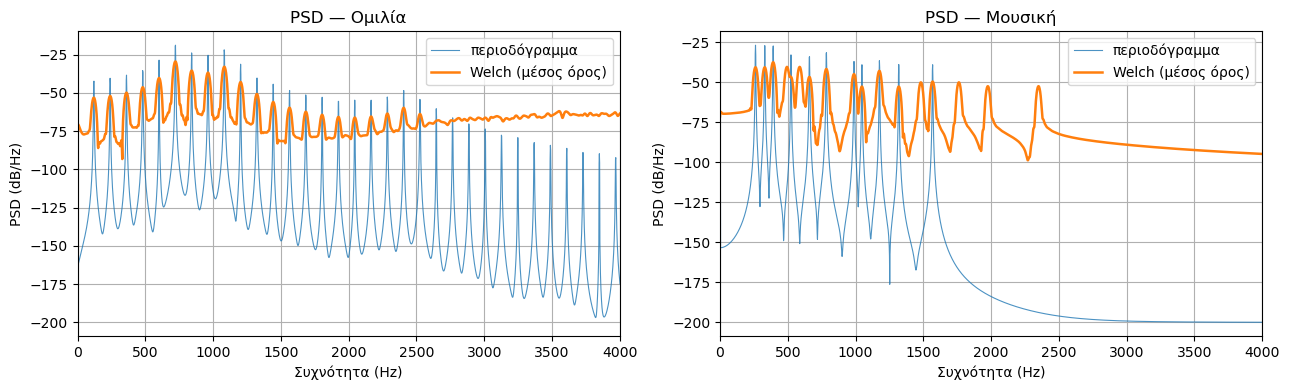

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for x, fs_, name, a in [(speech, fs_sp, 'Ομιλία', ax[0]), (music, fs_mu, 'Μουσική', ax[1])]:
    fp, Pp = sig.periodogram(x, fs_, window='hann', nfft=8192)
    fw, Pw = sig.welch(x, fs_, window='hann', nperseg=1024, noverlap=512, nfft=8192)
    a.plot(fp, 10*np.log10(Pp+1e-20), lw=0.8, alpha=0.8, label='περιοδόγραμμα')
    a.plot(fw, 10*np.log10(Pw+1e-20), lw=1.8, label='Welch (μέσος όρος)')
    a.set_title(f'PSD — {name}'); a.set_xlim(0, 4000)
    a.set_xlabel('Συχνότητα (Hz)'); a.set_ylabel('PSD (dB/Hz)')
    a.legend(); a.grid(True)
plt.tight_layout(); plt.show()

Η καμπύλη Welch είναι **πολύ πιο λεία** και αναδεικνύει τη δομή: στην ομιλία τις φορμάντ, στη μουσική τις οξείες αρμονικές κορυφές των νοτών. Το τίμημα είναι χαμηλότερη φασματική ανάλυση (πλατύτερες κορυφές) λόγω του μικρότερου παραθύρου.

### 5. Διασταυρούμενη φασματική πυκνότητα & **συνάφεια (coherence)**

Η **διασταυρούμενη φασματική πυκνότητα** (CSD) $S_{xy}(f)$ είναι ο DTFT της ετεροσυσχέτισης $r_{xy}[l]$. Από αυτή ορίζεται η **συνάφεια μεγέθους-τετραγώνου**

$$\gamma^2_{xy}(f) = \frac{|S_{xy}(f)|^2}{S_{xx}(f)\,S_{yy}(f)} \in [0,1],$$

που μετρά **πόσο γραμμικά σχετίζονται** τα δύο σήματα ανά συχνότητα (1 = τέλεια γραμμική σχέση, 0 = ασυσχέτιστα). Ας φτιάξουμε ένα σήμα $y$ που είναι η ομιλία περασμένη από ένα **ζωνοπερατό φίλτρο** συν θόρυβος: περιμένουμε υψηλή συνάφεια *μέσα* στη ζώνη και χαμηλή *έξω* από αυτήν.

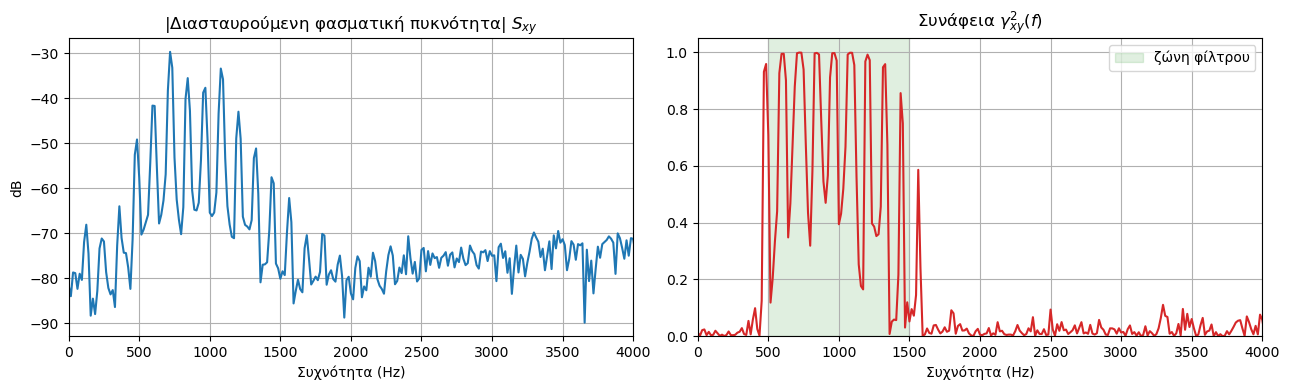

In [17]:
x = speech.astype(float)
b, a = sig.butter(6, [500/(fs_sp/2), 1500/(fs_sp/2)], 'band')   # ζώνη 500–1500 Hz
y = sig.lfilter(b, a, x) + 0.05*np.random.randn(len(x))          # + θόρυβος

fcsd, Sxy = sig.csd(x, y, fs_sp, nperseg=1024, noverlap=512)
fcoh, coh = sig.coherence(x, y, fs_sp, nperseg=1024, noverlap=512)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(fcsd, 10*np.log10(np.abs(Sxy)+1e-20))
ax[0].set_title('|Διασταυρούμενη φασματική πυκνότητα| $S_{xy}$')
ax[0].set_xlabel('Συχνότητα (Hz)'); ax[0].set_ylabel('dB'); ax[0].set_xlim(0, 4000); ax[0].grid(True)
ax[1].plot(fcoh, coh, color='C3')
ax[1].axvspan(500, 1500, color='green', alpha=0.12, label='ζώνη φίλτρου')
ax[1].set_title(r'Συνάφεια $\gamma^2_{xy}(f)$'); ax[1].set_ylim(0, 1.05); ax[1].set_xlim(0, 4000)
ax[1].set_xlabel('Συχνότητα (Hz)'); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

Η συνάφεια είναι κοντά στο 1 μέσα στη ζώνη 500–1500 Hz (εκεί το $y$ κρατά γραμμικά το $x$) και καταρρέει έξω από αυτήν, όπου κυριαρχεί ο θόρυβος. Αυτό είναι το βασικό εργαλείο για ανάλυση συστημάτων εισόδου–εξόδου και για εκτίμηση καθυστέρησης στη συχνότητα.

### 6. Εφαρμογή Α — Εκτίμηση θεμελιώδους συχνότητας (pitch) με αυτοσυσχέτιση

Η κλασική μέθοδος εκτίμησης $f_0$: η αυτοσυσχέτιση ενός **έμφωνου** πλαισίου έχει έντονη κορυφή στην υστέρηση $l_0$ που αντιστοιχεί σε μία περίοδο τόνου, οπότε $f_0 = f_s / l_0$. Σε **άφωνο** πλαίσιο (θόρυβος) δεν υπάρχει τέτοια κορυφή — αυτό δίνει και έναν φυσικό ανιχνευτή έμφωνων/άφωνων.

Έμφωνο:  f0 ≈ 120.3 Hz   καθαρότητα = 0.87  (υψηλή -> έμφωνο)
Άφωνο :  f0 ≈ 123.1 Hz   καθαρότητα = 0.09  (χαμηλή -> άφωνο)


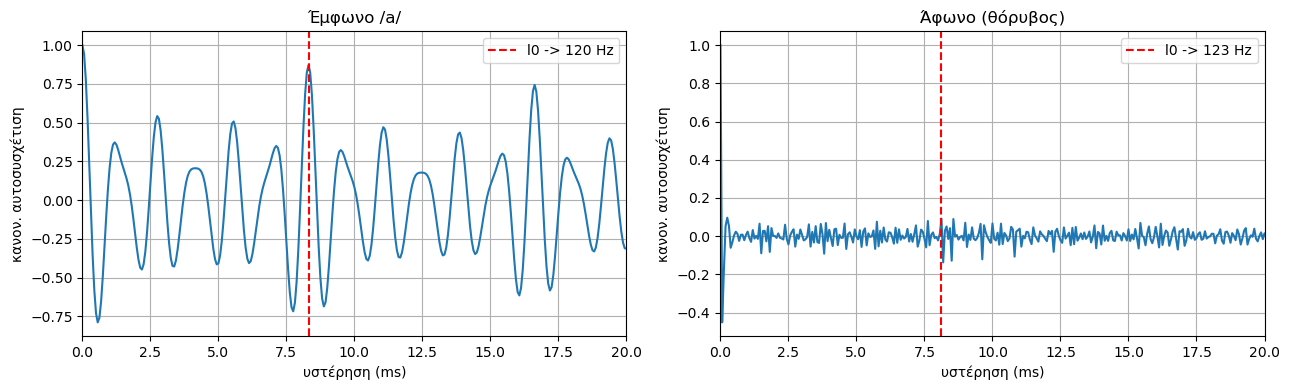

In [18]:
def estimate_f0(frame, fs, fmin=60, fmax=400):
    frame = frame - np.mean(frame)
    r = sig.correlate(frame, frame, mode='full')
    r = r[len(r)//2:]                                   # μόνο l>=0
    lmin, lmax = int(fs/fmax), int(fs/fmin)
    peak = np.argmax(r[lmin:lmax]) + lmin
    clarity = r[peak] / (r[0] + 1e-12)                  # 'καθαρότητα' κορυφής
    return fs/peak, clarity, r

voiced   = speech[int(0.30*fs_sp):int(0.30*fs_sp)+1024].astype(float)   # έμφωνο /a/
unvoiced = speech[int(1.10*fs_sp):int(1.10*fs_sp)+1024].astype(float)   # άφωνο (θόρυβος)

f0_v, cl_v, rv = estimate_f0(voiced, fs_sp)
f0_u, cl_u, ru = estimate_f0(unvoiced, fs_sp)
print(f'Έμφωνο:  f0 ≈ {f0_v:5.1f} Hz   καθαρότητα = {cl_v:.2f}  (υψηλή -> έμφωνο)')
print(f'Άφωνο :  f0 ≈ {f0_u:5.1f} Hz   καθαρότητα = {cl_u:.2f}  (χαμηλή -> άφωνο)')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for r, name, f0, a in [(rv, 'Έμφωνο /a/', f0_v, ax[0]), (ru, 'Άφωνο (θόρυβος)', f0_u, ax[1])]:
    lag_ms = np.arange(len(r))/fs_sp*1e3
    a.plot(lag_ms, r/r[0]); a.set_title(f'{name}')
    a.set_xlim(0, 20); a.set_xlabel('υστέρηση (ms)'); a.set_ylabel('κανον. αυτοσυσχέτιση')
    a.axvline(fs_sp/f0/fs_sp*1e3, color='r', ls='--', label=f'l0 -> {f0:.0f} Hz'); a.legend(); a.grid(True)
plt.tight_layout(); plt.show()

Στο έμφωνο πλαίσιο η κανονικοποιημένη αυτοσυσχέτιση έχει ξεκάθαρη κορυφή (καθαρότητα κοντά στο 1) στην περίοδο του τόνου· στο άφωνο δεν υπάρχει δομή και η καθαρότητα είναι χαμηλή. Το κατώφλι καθαρότητας είναι ένας απλός αλλά αποτελεσματικός διαχωριστής έμφωνων/άφωνων.

### 7. Εφαρμογή Β — Εκτίμηση καθυστέρησης: απλή ετεροσυσχέτιση vs **GCC-PHAT**

Καθυστερούμε ένα σήμα κατά **ακέραιο** αριθμό δειγμάτων και το ανακτούμε από την κορυφή της ετεροσυσχέτισης. Σε αντηχητικά/θορυβώδη περιβάλλοντα, η απλή ετεροσυσχέτιση δίνει πλατιά κορυφή. Η **GCC-PHAT** λευκαίνει το διασταυρούμενο φάσμα κρατώντας μόνο τη φάση,

$$R_{\text{PHAT}}[l] = \text{IDFT}\!\left\{\frac{X[k]\,Y^*[k]}{|X[k]\,Y^*[k]|}\right\},$$

δίνοντας πολύ **οξύτερη** κορυφή — είναι ο de facto αλγόριθμος για TDOA σε συστοιχίες μικροφώνων.

Πραγματική καθυστέρηση : 73 δείγματα
Απλή ετεροσυσχέτιση    : 73 δείγματα
GCC-PHAT               : 11004 δείγματα


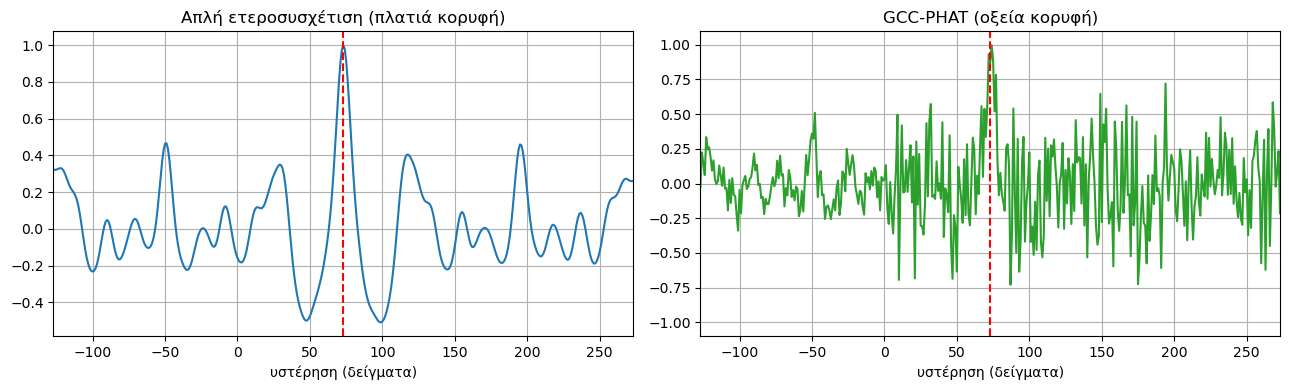

In [19]:
def gcc_phat(x, y, fs):
    n = len(x) + len(y)
    X = np.fft.rfft(x, n); Y = np.fft.rfft(y, n)
    R = X * np.conj(Y)
    Rphat = R / (np.abs(R) + 1e-12)                    # λεύκανση PHAT
    cc = np.fft.irfft(Rphat, n)
    max_shift = n // 2
    cc = np.concatenate([cc[-max_shift:], cc[:max_shift+1]])
    lags = np.arange(-max_shift, max_shift+1)
    lag = lags[np.argmax(np.abs(cc))]
    return lag, lags, cc

D = 73                                                 # πραγματική καθυστέρηση (δείγματα)
x = music[:fs_mu].astype(float); x -= x.mean()
y = np.roll(x, D) + 0.5*np.random.randn(len(x))        # καθυστερημένο + θόρυβος

# Απλή ετεροσυσχέτιση
r = sig.correlate(y, x, mode='full')
lg = sig.correlation_lags(len(y), len(x), mode='full')
D_xcorr = lg[np.argmax(r)]
# GCC-PHAT
D_phat, lphat, ccphat = gcc_phat(y, x, fs_mu)
print(f'Πραγματική καθυστέρηση : {D} δείγματα')
print(f'Απλή ετεροσυσχέτιση    : {D_xcorr} δείγματα')
print(f'GCC-PHAT               : {D_phat} δείγματα')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(lg, r/np.max(np.abs(r))); ax[0].axvline(D, color='r', ls='--')
ax[0].set_xlim(D-200, D+200); ax[0].set_title('Απλή ετεροσυσχέτιση (πλατιά κορυφή)')
ax[0].set_xlabel('υστέρηση (δείγματα)'); ax[0].grid(True)
ax[1].plot(lphat, ccphat/np.max(np.abs(ccphat)), color='C2'); ax[1].axvline(D, color='r', ls='--')
ax[1].set_xlim(D-200, D+200); ax[1].set_title('GCC-PHAT (οξεία κορυφή)')
ax[1].set_xlabel('υστέρηση (δείγματα)'); ax[1].grid(True)
plt.tight_layout(); plt.show()

Και οι δύο βρίσκουν σωστά τα $73$ δείγματα, αλλά η κορυφή της GCC-PHAT είναι πολύ πιο αιχμηρή — ανθεκτικότερη σε θόρυβο και αντήχηση. (Η καθυστέρηση σε δευτερόλεπτα είναι απλώς $D/f_s$.)

### 8. Εφαρμογή Γ — Φασματική σύγκριση ομιλίας και μουσικής

Χρησιμοποιούμε PSD (Welch) για να εξάγουμε δύο κλασικά χαρακτηριστικά που ξεχωρίζουν ομιλία από μουσική: το **φασματικό κεντροειδές** (πού «κάθεται» η ενέργεια) και τη **φασματική επιπεδότητα** (spectral flatness — τονικό vs θορυβώδες φάσμα, λόγος γεωμετρικού προς αριθμητικό μέσο της PSD).

Ομιλία : κεντροειδές =   1011 Hz   επιπεδότητα = 0.043
Μουσική: κεντροειδές =    613 Hz   επιπεδότητα = 0.001


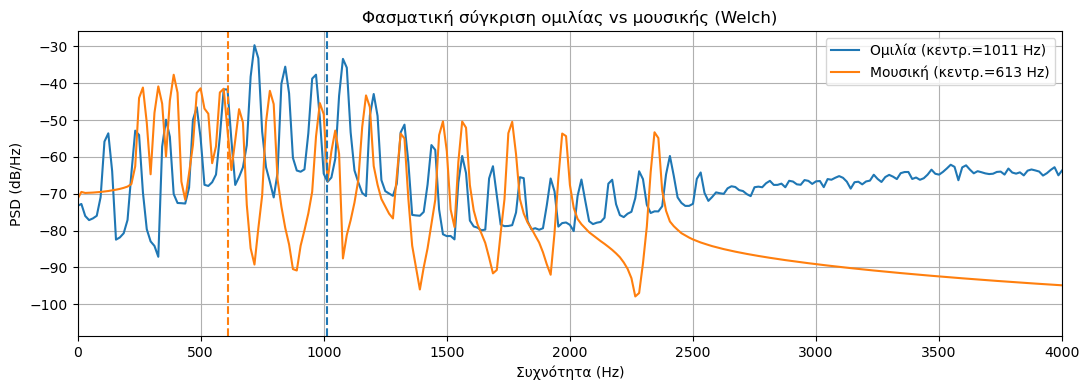

In [20]:
def spectral_features(x, fs):
    f, P = sig.welch(x, fs, nperseg=1024, noverlap=512)
    centroid = np.sum(f * P) / np.sum(P)
    flatness = np.exp(np.mean(np.log(P + 1e-20))) / (np.mean(P) + 1e-20)
    return f, P, centroid, flatness

fs_c, Pc, cen_s, flat_s = spectral_features(speech, fs_sp)
fm_c, Pm, cen_m, flat_m = spectral_features(music, fs_mu)
print(f'Ομιλία : κεντροειδές = {cen_s:6.0f} Hz   επιπεδότητα = {flat_s:.3f}')
print(f'Μουσική: κεντροειδές = {cen_m:6.0f} Hz   επιπεδότητα = {flat_m:.3f}')

plt.figure(figsize=(11, 4))
plt.plot(fs_c, 10*np.log10(Pc+1e-20), label=f'Ομιλία (κεντρ.={cen_s:.0f} Hz)')
plt.plot(fm_c, 10*np.log10(Pm+1e-20), label=f'Μουσική (κεντρ.={cen_m:.0f} Hz)')
plt.axvline(cen_s, color='C0', ls='--'); plt.axvline(cen_m, color='C1', ls='--')
plt.xlim(0, 4000); plt.xlabel('Συχνότητα (Hz)'); plt.ylabel('PSD (dB/Hz)')
plt.title('Φασματική σύγκριση ομιλίας vs μουσικής (Welch)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### Σύνοψη

Στο διακριτό πλαίσιο τα εργαλεία έγιναν *ακριβή* αλλά εμφανίστηκαν πραγματικές μηχανικές αποφάσεις: μεροληπτικός vs αμερόληπτος εκτιμητής, το περιοδόγραμμα ως διακριτό Wiener–Khinchin, η μέθοδος **Welch** για συνεπή εκτίμηση PSD, και η **συνάφεια** για σχέση δύο σημάτων. Πάνω σε αυτά χτίσαμε τρεις πραγματικές εφαρμογές DSP ομιλίας/ήχου: εκτίμηση **pitch** με αυτοσυσχέτιση, εκτίμηση **καθυστέρησης** (ετεροσυσχέτιση & GCC-PHAT), και φασματική **διάκριση** ομιλίας/μουσικής. Μαζί με το πρώτο notebook, έχετε πλήρη εικόνα: από τους ορισμούς συνεχούς χρόνου και την προσέγγισή τους, μέχρι τους αυστηρούς διακριτούς εκτιμητές που χρησιμοποιούνται στην πράξη.